## Digital Peer Conflict Exposure and PTSD Symptom Severity Code
Julianne Gerritsen

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import ttest_ind, f_oneway, spearmanr


# Load data
df = pd.read_csv("/CSVFiles/DigContent_ForPython.csv")

df.shape, df.head()

((256, 204),
   Q3_1 Q3_2 Q3_3 Q3_4 Q3_5 Q7_1 Q7_2 Q7_3 Q7_4 Q7_5  ... Q72_SIAS_Mean_0to4  \
 0   12   11   10   13    8    2    3    3    3    4  ...                1.1   
 1                             2    2    3    2    4  ...                 .7   
 2    7   10    8    9    9    4    5    3    4    3  ...               1.25   
 3    6    7    9   10   11    1    2    3    1    4  ...                1.1   
 4    8   11    8   11   11    3    4    2    3    4  ...                .15   
 
   Q73_Loneliness_Total Q73_Loneliness_Mean       Q74_PR_Mean  \
 0                   23    1.64285714285714                 5   
 1                   21                 1.5  4.55555555555556   
 2                   30    2.14285714285714  4.55555555555556   
 3                   31    2.21428571428571  4.22222222222222   
 4                   16    1.14285714285714                 6   
 
   Q74_Autonomy_Mean Q74_EnvMastery_Mean Q74_PersonalGrowth_Mean  \
 0  4.44444444444444    4.88888888888889     

In [2]:
# Define peer conflict 
peer_items = [
    "Q7_6",   # excluded by friends
    "Q7_7",   # devalued by friends
    "Q7_8",   # disconnected from peers
    "Q7_10",  # bullied by someone known personally
    "Q7_11",  # bullied by online friend
    "Q7_13",  # mass canceled by peer group
    "Q7_26"   # unwanted sexual advances from peers
]

# Confirm they are numeric
for col in peer_items:
    df[col] = pd.to_numeric(df[col], errors="coerce")


In [3]:
# Create subscales:
# exclusion = 6,7,8   
# cyberbullying = 10,11,13
# sexual = 26 
exclusion_items = ["Q7_6", "Q7_7", "Q7_8"]
cyberbullying_items = ["Q7_10", "Q7_11","Q7_13"]
sexual_advances_item = ["Q7_26"]

df["peer_exclusion_sum"] = df[exclusion_items].sum(axis=1, skipna=True)
df["peer_cyberbullying_sum"] = df[cyberbullying_items].sum(axis=1, skipna=True)
df["peer_unwanted_sexual_advances"] = df["Q7_26"]

# total peer conflict score across all 8 items
df["peer_conflict_all"] = df[peer_items].sum(axis=1, skipna=True)

df["peer_conflict_total_experienced"] = df[peer_items].apply(
    lambda row: sum([x for x in row if x >= 3]),
    axis=1
)

# average score across the 8 items
df["peer_conflict_mean"] = df[peer_items].mean(axis=1, skipna=True)


In [4]:
# Cut-score / exposure grouping:
# 1-2 = minimal / never
# 3+  = experienced
# To create a participant-level group, each individual's HIGHEST score 
# across the peer-conflict items was used
df["peer_conflict_max"] = df[peer_items].max(axis=1, skipna=True)

df["peer_conflict_binary"] = np.where(
    df["peer_conflict_max"] >= 3,
    "Experienced (3+)",
    "Minimal/None (1-2)"
)

# Optional 3-level grouping
def three_level_group(x):
    if pd.isna(x):
        return np.nan
    elif x <= 2:
        return "1-2 Minimal/None"
    elif x == 3:
        return "3 Moderate"
    else:
        return "4-5 Higher"

df["peer_conflict_3level"] = df["peer_conflict_max"].apply(three_level_group)


In [5]:
# Frequency counts
binary_counts = df["peer_conflict_binary"].value_counts(dropna=False)
three_level_counts = df["peer_conflict_3level"].value_counts(dropna=False).sort_index()

print("\nBINARY COUNTS")
print(binary_counts)

print("\nTHREE-LEVEL COUNTS")
print(three_level_counts)


BINARY COUNTS
peer_conflict_binary
Experienced (3+)      195
Minimal/None (1-2)     61
Name: count, dtype: int64

THREE-LEVEL COUNTS
peer_conflict_3level
1-2 Minimal/None     60
3 Moderate           85
4-5 Higher          110
NaN                   1
Name: count, dtype: int64


In [6]:
# Item-level counts
# Number of people that selected each response level for each peer item

print("\nITEM-LEVEL COUNTS")
for col in peer_items:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False).sort_index())


ITEM-LEVEL COUNTS

Q7_6
Q7_6
1.0    44
2.0    63
3.0    90
4.0    50
5.0     8
NaN     1
Name: count, dtype: int64

Q7_7
Q7_7
1.0    90
2.0    74
3.0    61
4.0    25
5.0     3
NaN     3
Name: count, dtype: int64

Q7_8
Q7_8
1.0    64
2.0    75
3.0    74
4.0    30
5.0    10
NaN     3
Name: count, dtype: int64

Q7_10
Q7_10
1.0    114
2.0     42
3.0     54
4.0     33
5.0     12
NaN      1
Name: count, dtype: int64

Q7_11
Q7_11
1.0    198
2.0     25
3.0     17
4.0      7
5.0      7
NaN      2
Name: count, dtype: int64

Q7_13
Q7_13
1.0    205
2.0     17
3.0     23
4.0      6
5.0      4
NaN      1
Name: count, dtype: int64

Q7_26
Q7_26
1.0    155
2.0     45
3.0     30
4.0     17
5.0      8
NaN      1
Name: count, dtype: int64


In [7]:
# Number of people who had any peer conflict item at 3, 4, or 5 
df["any_peer_item_3"] = (df[peer_items] == 3).any(axis=1)
df["any_peer_item_4_5"] = df[peer_items].isin([4, 5]).any(axis=1)

print("\nParticipants with ANY peer item scored exactly 3:")
print(df["any_peer_item_3"].sum())

print("\nParticipants with ANY peer item scored 4 or 5:")
print(df["any_peer_item_4_5"].sum())


Participants with ANY peer item scored exactly 3:
171

Participants with ANY peer item scored 4 or 5:
110


In [8]:
# Save file
output_file = "DigContent_PeerConflictScores.xlsx"
df.to_excel(output_file, index=False)

print(f"\nSaved cleaned dataset to: {output_file}")


Saved cleaned dataset to: DigContent_PeerConflictScores.xlsx


In [9]:
# Define key variables
pcl_col = "Q71_PCL5_Total_0to4"

peer_total_all_col = "peer_conflict_all"
peer_total_exp_col = "peer_conflict_total_experienced"
peer_mean_col = "peer_conflict_mean"
peer_max_col = "peer_conflict_max"
peer_binary_col = "peer_conflict_binary"
peer_3level_col = "peer_conflict_3level"

# make sure key vars are numeric where needed
numeric_cols = [pcl_col, peer_total_all_col, peer_total_exp_col, peer_mean_col, peer_max_col]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")


In [10]:
# Count / sample sizes
print("\n==============================")
print("GROUP COUNTS")
print("==============================")

print("\nBinary counts:")
print(df[peer_binary_col].value_counts(dropna=False))

print("\n3-level counts:")
print(df[peer_3level_col].value_counts(dropna=False))



GROUP COUNTS

Binary counts:
peer_conflict_binary
Experienced (3+)      195
Minimal/None (1-2)     61
Name: count, dtype: int64

3-level counts:
peer_conflict_3level
4-5 Higher          110
3 Moderate           85
1-2 Minimal/None     60
NaN                   1
Name: count, dtype: int64


In [11]:
# Descrptive stats for PTSD total by group 
print("\n==============================")
print("PCL-5 DESCRIPTIVES BY GROUP")
print("==============================")

binary_desc = df.groupby(peer_binary_col)[pcl_col].agg(["count", "mean", "std", "median", "min", "max"])
print("\nBy binary group:")
print(binary_desc)

three_desc = df.groupby(peer_3level_col)[pcl_col].agg(["count", "mean", "std", "median", "min", "max"])
print("\nBy 3-level group:")
print(three_desc)



PCL-5 DESCRIPTIVES BY GROUP

By binary group:
                      count       mean        std  median  min    max
peer_conflict_binary                                                 
Experienced (3+)        195  25.420513  24.512727    18.0  0.0  136.0
Minimal/None (1-2)       60  10.216667  12.830171     5.0  0.0   65.0

By 3-level group:
                      count       mean        std  median  min    max
peer_conflict_3level                                                 
1-2 Minimal/None         60  10.216667  12.830171     5.0  0.0   65.0
3 Moderate               85  15.988235  16.635085    11.0  0.0   68.0
4-5 Higher              110  32.709091  27.077648    26.5  0.0  136.0


In [1]:
# Welch t-test
# Experienced (3+) vs Minimal/None (1-2)
print("\n==============================")
print("WELCH T-TEST: EXPERIENCED VS MINIMAL/NONE")
print("==============================")

exp_group = df.loc[df[peer_binary_col] == "Experienced (3+)", pcl_col].dropna()
min_group = df.loc[df[peer_binary_col] == "Minimal/None (1-2)", pcl_col].dropna()

t_stat, p_val = ttest_ind(exp_group, min_group, equal_var=False)

print(f"Experienced n = {len(exp_group)}")
print(f"Minimal/None n = {len(min_group)}")
print(f"Experienced mean = {exp_group.mean():.2f}")
print(f"Minimal/None mean = {min_group.mean():.2f}")
print(f"t = {t_stat:.4f}")
print(f"p = {p_val:.4f}")

n_exp, n_min = len(exp_group), len(min_group)
var_exp, var_min = exp_group.var(ddof=1), min_group.var(ddof=1)

pooled_sd = np.sqrt(((n_exp - 1) * var_exp + (n_min - 1) * var_min) / (n_exp + n_min - 2))
cohens_d = (exp_group.mean() - min_group.mean()) / pooled_sd

print(f"Cohen's d = {cohens_d:.3f}")


WELCH T-TEST: EXPERIENCED VS MINIMAL/NONE


NameError: name 'df' is not defined

In [13]:
# One-way ANOVA
# 1-2 Minimal/None vs 3 Moderate vs 4-5 Higher
print("\n==============================")
print("ANOVA: 3-LEVEL PEER CONFLICT GROUPS")
print("==============================")

g12 = df.loc[df[peer_3level_col] == "1-2 Minimal/None", pcl_col].dropna()
g3 = df.loc[df[peer_3level_col] == "3 Moderate", pcl_col].dropna()
g45 = df.loc[df[peer_3level_col] == "4-5 Higher", pcl_col].dropna()

print(f"1-2 Minimal/None n = {len(g12)}")
print(f"3 Moderate n = {len(g3)}")
print(f"4-5 Higher n = {len(g45)}")

if len(g12) > 1 and len(g3) > 1 and len(g45) > 1:
    f_stat, p_anova = f_oneway(g12, g3, g45)
    print(f"1-2 mean = {g12.mean():.2f}")
    print(f"3 mean = {g3.mean():.2f}")
    print(f"4-5 mean = {g45.mean():.2f}")
    print(f"F = {f_stat:.4f}")
    print(f"p = {p_anova:.4f}")
else:
    print("One or more groups are too small for ANOVA.")



ANOVA: 3-LEVEL PEER CONFLICT GROUPS
1-2 Minimal/None n = 60
3 Moderate n = 85
4-5 Higher n = 110
1-2 mean = 10.22
3 mean = 15.99
4-5 mean = 32.71
F = 26.8037
p = 0.0000


In [14]:
# Spearman correlations with PTSD total
# Using all participant responses
print("\n==============================")
print("SPEARMAN CORRELATIONS WITH PCL-5")
print("==============================")

corr_vars = [
    peer_total_all_col,
    peer_total_exp_col,
    peer_mean_col,
    peer_max_col
]

for var in corr_vars:
    temp = df[[var, pcl_col]].dropna()
    rho, p_corr = spearmanr(temp[var], temp[pcl_col])
    print(f"\n{var} vs {pcl_col}")
    print(f"rho = {rho:.4f}")
    print(f"p = {p_corr:.4f}")
    print(f"n = {len(temp)}")



SPEARMAN CORRELATIONS WITH PCL-5

peer_conflict_all vs Q71_PCL5_Total_0to4
rho = 0.4995
p = 0.0000
n = 255

peer_conflict_total_experienced vs Q71_PCL5_Total_0to4
rho = 0.4578
p = 0.0000
n = 255

peer_conflict_mean vs Q71_PCL5_Total_0to4
rho = 0.5008
p = 0.0000
n = 255

peer_conflict_max vs Q71_PCL5_Total_0to4
rho = 0.4530
p = 0.0000
n = 255


In [15]:
# Total who experienced peer conflict (3+)
print("\n==============================")
print("EXPERIENCED-ONLY ANALYSIS (3+)")
print("==============================")

df_exp = df[df[peer_binary_col] == "Experienced (3+)"].copy()

print(f"Experienced-only n = {len(df_exp)}")
print(f"Mean PCL-5 = {df_exp[pcl_col].mean():.2f}")
print(f"SD PCL-5 = {df_exp[pcl_col].std():.2f}")
print(f"Mean experienced-only peer conflict total = {df_exp[peer_total_exp_col].mean():.2f}")
print(f"SD experienced-only peer conflict total = {df_exp[peer_total_exp_col].std():.2f}")

# Spearman within experienced-only participants
temp_exp = df_exp[[peer_total_exp_col, pcl_col]].dropna()
rho_exp, p_exp = spearmanr(temp_exp[peer_total_exp_col], temp_exp[pcl_col])

print("\nExperienced-only correlation:")
print(f"{peer_total_exp_col} vs {pcl_col}")
print(f"rho = {rho_exp:.4f}")
print(f"p = {p_exp:.4f}")
print(f"n = {len(temp_exp)}")


EXPERIENCED-ONLY ANALYSIS (3+)
Experienced-only n = 195
Mean PCL-5 = 25.42
SD PCL-5 = 24.51
Mean experienced-only peer conflict total = 10.15
SD experienced-only peer conflict total = 6.02

Experienced-only correlation:
peer_conflict_total_experienced vs Q71_PCL5_Total_0to4
rho = 0.3987
p = 0.0000
n = 195


In [16]:
# Correlation within three moderate only
print("\n==============================")
print("3 MODERATE ONLY")
print("==============================")

df_3 = df[df[peer_3level_col] == "3 Moderate"].copy()
temp_3 = df_3[[peer_total_exp_col, pcl_col]].dropna()

if len(temp_3) > 2:
    rho_3, p_3 = spearmanr(temp_3[peer_total_exp_col], temp_3[pcl_col])
    print(f"n = {len(temp_3)}")
    print(f"rho = {rho_3:.4f}")
    print(f"p = {p_3:.4f}")
else:
    print("Not enough data in 3 Moderate group.")


3 MODERATE ONLY
n = 85
rho = 0.0269
p = 0.8071


In [17]:
# Correlation within 4–5 higher only 

print("\n==============================")
print("4-5 HIGHER ONLY")
print("==============================")

df_45 = df[df[peer_3level_col] == "4-5 Higher"].copy()
temp_45 = df_45[[peer_total_exp_col, pcl_col]].dropna()

if len(temp_45) > 2:
    rho_45, p_45 = spearmanr(temp_45[peer_total_exp_col], temp_45[pcl_col])
    print(f"n = {len(temp_45)}")
    print(f"rho = {rho_45:.4f}")
    print(f"p = {p_45:.4f}")
else:
    print("Not enough data in 4-5 Higher group.")



4-5 HIGHER ONLY
n = 110
rho = 0.3880
p = 0.0000


In [18]:
# Small results table
results_cols = [
    pcl_col,
    peer_total_all_col,
    peer_total_exp_col,
    peer_mean_col,
    peer_max_col,
    peer_binary_col,
    peer_3level_col
]

analysis_df = df[results_cols].copy()
analysis_df.to_excel("CUP_AnalysisFile.xlsx", index=False)

print("\nSaved: CUP_AnalysisFile.xlsx")


Saved: CUP_AnalysisFile.xlsx


In [19]:
print([col for col in df.columns if "Q74" in col or "Trust" in col or "Threat" in col])

['Q74_1', 'Q74_2', 'Q74_3', 'Q74_4', 'Q74_5', 'Q74_6', 'Q74_7', 'Q74_8', 'Q74_9', 'Q74_10', 'Q74_11', 'Q74_12', 'Q74_13', 'Q74_14', 'Q74_15', 'Q74_16', 'Q74_17', 'Q74_18', 'Q74_19', 'Q74_20', 'Q74_21', 'Q74_22', 'Q74_23', 'Q74_24', 'Q74_25', 'Q74_26', 'Q74_27', 'Q74_28', 'Q74_29', 'Q74_30', 'Q74_31', 'Q74_32', 'Q74_33', 'Q74_34', 'Q74_35', 'Q74_36', 'Q74_37', 'Q74_38', 'Q74_39', 'Q74_40', 'Q74_41', 'Q74_42', 'Q74_43', 'Q74_44', 'Q74_45', 'Q74_46', 'Q74_47', 'Q74_48', 'Q74_49', 'Q74_50', 'Q74_51', 'Q74_52', 'Q74_53', 'Q74_54', 'Q70_ThreatHarm', 'Q70_ReliabilityTrust', 'Q74_PR_Mean', 'Q74_Autonomy_Mean', 'Q74_EnvMastery_Mean', 'Q74_PersonalGrowth_Mean', 'Q74_PurposeLife_Mean', 'Q74_SelfAccept_Mean', 'Q74_Ryff_Total_Mean']


In [20]:
# Define new subscales for further analyses
threat_col = "Q70_ThreatHarm"
env_mastery_col = "Q74_EnvMastery_Mean"
personal_relations_col = "Q74_PR_Mean"
trust_col = "Q70_ReliabilityTrust"

In [21]:
print("SUBSCALE CORRELATIONS WITH PTSD")
print("==============================")

subscale_vars = [
    threat_col,
    env_mastery_col,
    personal_relations_col,
    trust_col
]

for var in subscale_vars:
    temp = df[[var, pcl_col]].dropna()
    rho, p_val = spearmanr(temp[var], temp[pcl_col])

    print(f"\n{var} vs PTSD")
    print(f"rho = {rho:.4f}")
    print(f"p = {p_val:.4f}")
    print(f"n = {len(temp)}")

SUBSCALE CORRELATIONS WITH PTSD

Q70_ThreatHarm vs PTSD
rho = 0.3928
p = 0.0000
n = 255

Q74_EnvMastery_Mean vs PTSD
rho = -0.4405
p = 0.0000
n = 255

Q74_PR_Mean vs PTSD
rho = -0.5053
p = 0.0000
n = 255

Q70_ReliabilityTrust vs PTSD
rho = 0.0374
p = 0.5517
n = 255


In [22]:
print("SUBSCALE CORRELATIONS WITH PEER CONFLICT")
print("==============================")

for var in subscale_vars:
    temp = df[[var, peer_total_exp_col]].dropna()
    rho, p_val = spearmanr(temp[var], temp[peer_total_exp_col])

    print(f"\n{var} vs Peer Conflict (experienced)")
    print(f"rho = {rho:.4f}")
    print(f"p = {p_val:.4f}")
    print(f"n = {len(temp)}")

SUBSCALE CORRELATIONS WITH PEER CONFLICT

Q70_ThreatHarm vs Peer Conflict (experienced)
rho = 0.1104
p = 0.0780
n = 256

Q74_EnvMastery_Mean vs Peer Conflict (experienced)
rho = -0.1806
p = 0.0037
n = 256

Q74_PR_Mean vs Peer Conflict (experienced)
rho = -0.3040
p = 0.0000
n = 256

Q70_ReliabilityTrust vs Peer Conflict (experienced)
rho = 0.0067
p = 0.9152
n = 256


In [23]:
print("SUBSCALES WITHIN EXPERIENCED GROUP")
print("==============================")

df_exp = df[df[peer_binary_col] == "Experienced (3+)"]

for var in subscale_vars:
    temp = df_exp[[var, pcl_col]].dropna()
    rho, p_val = spearmanr(temp[var], temp[pcl_col])

    print(f"\n{var} vs PTSD (experienced only)")
    print(f"rho = {rho:.4f}")
    print(f"p = {p_val:.4f}")
    print(f"n = {len(temp)}")

SUBSCALES WITHIN EXPERIENCED GROUP

Q70_ThreatHarm vs PTSD (experienced only)
rho = 0.4128
p = 0.0000
n = 195

Q74_EnvMastery_Mean vs PTSD (experienced only)
rho = -0.4363
p = 0.0000
n = 195

Q74_PR_Mean vs PTSD (experienced only)
rho = -0.5212
p = 0.0000
n = 195

Q70_ReliabilityTrust vs PTSD (experienced only)
rho = 0.0399
p = 0.5798
n = 195


/var/folders/9j/xb1n61yn03z9934168ncghb80000gn/T/ipykernel_91089/532677646.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(display_labels, fontsize=tick_size)


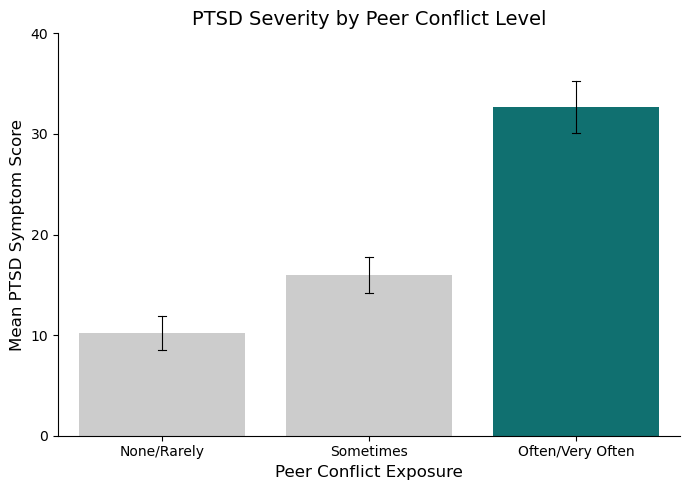

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# Settings
title_size = 14
label_size = 12
tick_size = 10


colors = ["#CCCCCC", "#CCCCCC", "#008080"]

order = ["1-2 Minimal/None", "3 Moderate", "4-5 Higher"]
display_labels = ["None/Rarely", "Sometimes", "Often/Very Often"]

# Plot
plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=df,
    x="peer_conflict_3level",
    y=pcl_col,
    order=order,
    hue="peer_conflict_3level",
    palette=colors,
    legend=False,
    errorbar=("se", 1),  # standard error
    capsize=0.04,         # adds the little horizontal "tails"
    err_kws={
        "color": "black",   # makes error bars black
        "linewidth": 0.8    # controls thickness
    }
)

# Titles & labels
plt.title("PTSD Severity by Peer Conflict Level", fontsize=title_size)
plt.xlabel("Peer Conflict Exposure", fontsize=label_size)
plt.ylabel("Mean PTSD Symptom Score", fontsize=label_size)

# Ticks
ax.set_xticklabels(display_labels, fontsize=tick_size)
plt.yticks([0, 10, 20, 30, 40], fontsize=tick_size)
plt.ylim(0, 40)

# Clean display
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig('/Visuals/PTSD-PeerConflict_Bar.png', 
            dpi=300, # High resolution
            bbox_inches='tight') # Ensure layout fits
plt.show()

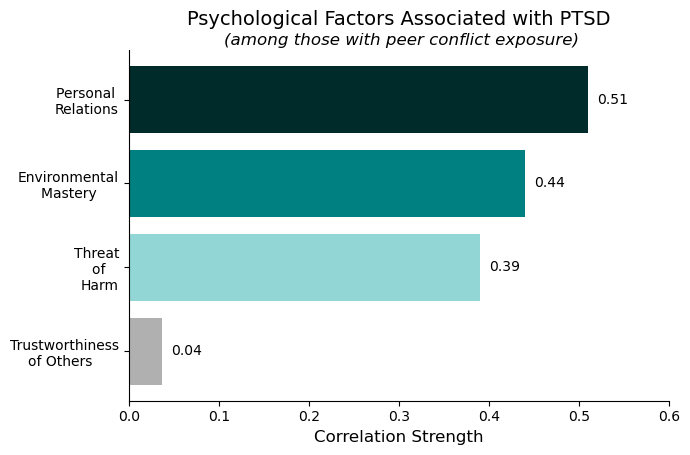

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Settings 
title_size = 14
subtitle_size = 12
label_size = 12
tick_size = 10

bar_colors = ["#B0B0B0", "#92D6D6", "#008080", "#002B2B"]

# Data
rank_df = pd.DataFrame({
    "Subscale": ["Threat\nof   \nHarm", "Environmental\nMastery     ", "Personal \nRelations", "Trustworthiness\nof Others      "],
    "Rho": [0.39, -0.44, -0.51, 0.037]
})

rank_df["AbsRho"] = rank_df["Rho"].abs()
rank_df = rank_df.sort_values("AbsRho")

# Plot
fig, ax = plt.subplots(figsize=(7,5))

ax.barh(
    rank_df["Subscale"],
    rank_df["AbsRho"],
    color=bar_colors
)

# Main title
ax.set_title("Psychological Factors Associated with PTSD", fontsize=title_size, pad=18)

# Subtitle
fig.text(
    0.58, 0.83,
    "(among those with peer conflict exposure)",
    ha="center",
    fontsize=subtitle_size,
    style="italic"
)

# Axes labels
ax.set_xlabel("Correlation Strength", fontsize=label_size)
ax.set_ylabel("")

# Ticks
ax.tick_params(axis="x", labelsize=tick_size)
ax.tick_params(axis="y", labelsize=tick_size)

ax.set_xlim(0, 0.6)
ax.set_xticks([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6])

# Value labels
for i, v in enumerate(rank_df["AbsRho"]):
    ax.text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=tick_size)

# Clean display
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Space for subtitle
plt.tight_layout(rect=[0, 0, 1, 0.93])

plt.savefig(
    '/Visuals/PTSD-SubscaleStrength_Bar.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [26]:
for col in peer_items:
    print(col, df[[col, pcl_col]].corr(method="spearman").iloc[0,1])

Q7_6 0.3172308525162466
Q7_7 0.2764833066907463
Q7_8 0.3219570415850496
Q7_10 0.4178887085820394
Q7_11 0.3946412413201219
Q7_13 0.2653489868686208
Q7_26 0.2797370277919713


In [27]:
# Select variables
X = df[[
    "Q70_ThreatHarm",
    "Q74_EnvMastery_Mean",
    "Q74_PR_Mean",
    "Q70_ReliabilityTrust"
]].copy()

y = df[pcl_col].copy()

# Force numeric
X = X.apply(pd.to_numeric, errors="coerce")
y = pd.to_numeric(y, errors="coerce")

# Drop missing
data = pd.concat([X, y], axis=1).dropna()

X_clean = data[[
    "Q70_ThreatHarm",
    "Q74_EnvMastery_Mean",
    "Q74_PR_Mean",
    "Q70_ReliabilityTrust"
]]
y_clean = data[pcl_col]

# Add constant
X_clean = sm.add_constant(X_clean)

# Run regression
model = sm.OLS(y_clean, X_clean).fit()

# Print results
print(model.summary())

                             OLS Regression Results                            
Dep. Variable:     Q71_PCL5_Total_0to4   R-squared:                       0.409
Model:                             OLS   Adj. R-squared:                  0.399
Method:                  Least Squares   F-statistic:                     43.17
Date:                 Sun, 20 Sep 2026   Prob (F-statistic):           1.61e-27
Time:                         16:15:08   Log-Likelihood:                -1096.3
No. Observations:                  255   AIC:                             2203.
Df Residuals:                      250   BIC:                             2220.
Df Model:                            4                                         
Covariance Type:             nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 